## Step 2: Data Collection & Understanding
Load the Olist E-Commerce datasets (Orders, Items, and Reviews) from the local `dataset` subfolder.

Merge the tables to create a unified user-item interaction dataframe and isolate the target variables (`user_id`, `product_id`, `rating`, `price`).

Handle initial missing values in the target variable and generate a comprehensive dataset overview.

In [8]:
import pandas as pd
import os

# Define the updated absolute path pointing to the new 'dataset' subfolder
data_path = r"C:\Users\Nathan\OneDrive\Documents\AIM\Capstone Project\dataset"

try:
    print(f"Attempting to load datasets from: {data_path}...")
    
    # Load the relevant datasets from the folder
    orders = pd.read_csv(os.path.join(data_path, 'olist_orders_dataset.csv'))
    items = pd.read_csv(os.path.join(data_path, 'olist_order_items_dataset.csv'))
    reviews = pd.read_csv(os.path.join(data_path, 'olist_order_reviews_dataset.csv'))
    print("Files successfully loaded!\n")
    
    # 1. Merge items and orders on 'order_id' to link products to customers
    df_merged = pd.merge(items, orders[['order_id', 'customer_id']], on='order_id', how='left')

    # 2. Merge the result with reviews to get the review_score (this will act as our rating)
    df_merged = pd.merge(df_merged, reviews[['order_id', 'review_score']], on='order_id', how='left')

    # Select and rename columns to match the standard format for Recommendation Systems
    df = df_merged[['customer_id', 'product_id', 'review_score', 'price']].copy()
    df.rename(columns={'customer_id': 'user_id', 'review_score': 'rating'}, inplace=True)

    # Drop any rows where the user didn't leave a rating (we need ratings to train the model)
    df.dropna(subset=['rating'], inplace=True)

    # Display dataset overview
    print("Olist Dataset Info:")
    df.info()

    print("\nFirst 5 rows:")
    print(df.head())

except FileNotFoundError as e:
    print(f"\n❌ Error: {e}")
    print("Please make sure you have created the 'dataset' folder and unzipped the CSV files directly inside it.")
    print("Ensure the file is in the correct destination")

Attempting to load datasets from: C:\Users\Nathan\OneDrive\Documents\AIM\Capstone Project\dataset...
Files successfully loaded!

Olist Dataset Info:
<class 'pandas.DataFrame'>
Index: 112372 entries, 0 to 113313
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     112372 non-null  str    
 1   product_id  112372 non-null  str    
 2   rating      112372 non-null  float64
 3   price       112372 non-null  float64
dtypes: float64(2), str(2)
memory usage: 11.2 MB

First 5 rows:
                            user_id                        product_id  rating  \
0  3ce436f183e68e07877b285a838db11a  4244733e06e7ecb4970a6e2683c13e61     5.0   
1  f6dd3ec061db4e3987629fe6b26e5cce  e5f2d52b802189ee658865ca93d83a8f     4.0   
2  6489ae5e4333f3693df5ad4372dab6d3  c777355d18b72b67abbeef9df44fd0fd     5.0   
3  d4eb9395c8c0431ee92fce09860c5a06  7634da152a4610f1595efa32f14722fc     4.0   
4  58dbd0b2d70206bf40e62cd34e84d795 

## Step 3: Data Preprocessing, Applied EDA & Feature Engineering
Clean the data by removing duplicate interactions and applying median imputation for missing prices.

Perform Exploratory Data Analysis (EDA) to visualize the distribution of explicit ratings and log-scaled item prices.

Engineer domain-specific features: calculate user engagement (`interaction_count`) and bin users into socioeconomic proxies (`price_tier`) using statistical quantiles.

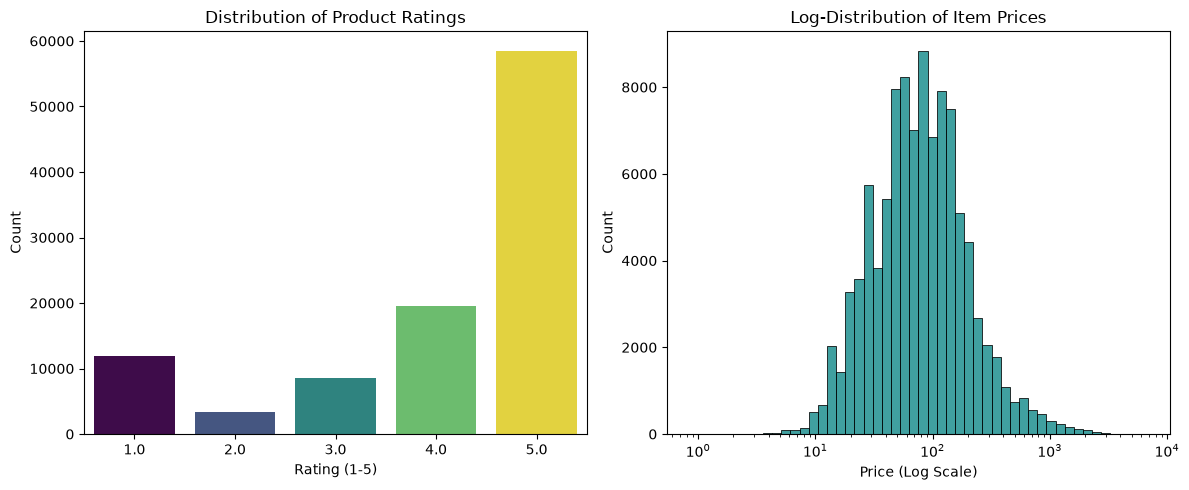


Cleaned and Engineered Data (First 3 rows):
                            user_id                        product_id  rating  \
0  3ce436f183e68e07877b285a838db11a  4244733e06e7ecb4970a6e2683c13e61     5.0   
1  f6dd3ec061db4e3987629fe6b26e5cce  e5f2d52b802189ee658865ca93d83a8f     4.0   
2  6489ae5e4333f3693df5ad4372dab6d3  c777355d18b72b67abbeef9df44fd0fd     5.0   

   price  interaction_count  avg_purchase_price price_tier  
0   58.9                  1                58.9  Mid-Range  
1  239.9                  1               239.9    Premium  
2  199.0                  1               199.0    Premium  


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

# Clean Data: Drop exact duplicate interactions to avoid model bias
df.drop_duplicates(inplace=True)

# Clean Data: Fill any missing prices with the median price
df['price'] = df['price'].fillna(df['price'].median())

# Applied EDA: Visualize the distribution of ratings
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Added hue and legend=False to fix Seaborn warning
sns.countplot(data=df, x='rating', hue='rating', palette='viridis', legend=False)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating (1-5)')
plt.ylabel('Count')

# Applied EDA: Visualize the distribution of prices (log scale due to right-skewness)
plt.subplot(1, 2, 2)
sns.histplot(df['price'], bins=50, log_scale=True, color='teal')
plt.title('Log-Distribution of Item Prices')
plt.xlabel('Price (Log Scale)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Feature Engineering: Calculate total interactions per user (User Activity)
user_activity = df.groupby('user_id').size().reset_index(name='interaction_count')
df = df.merge(user_activity, on='user_id')

# Feature Engineering: Create a 'Socioeconomic Proxy' based on average purchase price per user
# We will bin users into 'Budget', 'Mid-Range', and 'Premium' shoppers
user_avg_price = df.groupby('user_id')['price'].mean().reset_index(name='avg_purchase_price')
df = df.merge(user_avg_price, on='user_id')

# Binning into tiers using quantiles (33rd and 66th percentiles)
p33 = df['avg_purchase_price'].quantile(0.33)
p66 = df['avg_purchase_price'].quantile(0.66)

def assign_price_tier(price):
    if price <= p33:
        return 'Budget'
    elif price <= p66:
        return 'Mid-Range'
    else:
        return 'Premium'

df['price_tier'] = df['avg_purchase_price'].apply(assign_price_tier)

print("\nCleaned and Engineered Data (First 3 rows):")
print(df.head(3))

## Step 4: Model Implementation & Tuning
Implement a Collaborative Filtering architecture using Singular Value Decomposition (SVD) via the `surprise` library.

Execute an exhaustive hyperparameter search using `GridSearchCV` to optimize the learning rate, regularization, and latent factors.

Extract the best performing model architecture based on the lowest RMSE score.

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import GridSearchCV, train_test_split, cross_validate
from surprise import accuracy
from surprise import NormalPredictor
import time

# Baseline Model Evaluation
print("Evaluating Baseline Model (Normal Predictor)...")
baseline_results = cross_validate(NormalPredictor(), data_surprise, measures=['RMSE'], cv=3, n_jobs=-1)
baseline_rmse = baseline_results['test_rmse'].mean()

print(f"Baseline Model RMSE: {baseline_rmse:.4f}")
print("Moving to advanced model implementation (SVD)...\n")


# Define the reader and load data into Surprise's format
reader = Reader(rating_scale=(1, 5))
data_surprise = Dataset.load_from_df(df[['user_id', 'product_id', 'rating']], reader)

# Define an expanded hyperparameter grid for deep optimization
param_grid = {
    'n_factors': [50, 100, 150], 
    'n_epochs': [20, 30, 40, 50],         # Expanded up to 50 iterations
    'lr_all': [0.002, 0.005, 0.01, 0.02], # Testing smaller micro-steps and larger leaps
    'reg_all': [0.02, 0.05, 0.1, 0.2]     # Testing light to aggressive penalties
}

print("\nStarting Expanded Hyperparameter Tuning (Testing 192 combinations)...")
print("This will take approximately 4-7 minutes. Please wait.")
start_time = time.time()

# Initialize GridSearchCV with the SVD algorithm and our expanded grid
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
# Run the grid search on the entire dataset
gs.fit(data_surprise)

# Extract the best performing model based on RMSE
print(f"Tuning completed in {time.time() - start_time:.2f} seconds.")
print(f"Best RMSE score achieved during tuning: {gs.best_score['rmse']:.4f}")
print(f"Optimal Hyperparameters found: {gs.best_params['rmse']}")

# Save the best model architecture for the next step
best_model = gs.best_estimator['rmse']

Evaluating Baseline Model (Normal Predictor)...
Baseline Model RMSE: 1.7328
Moving to advanced model implementation (SVD)...


Starting Expanded Hyperparameter Tuning (Testing 192 combinations)...
This will take approximately 5-8 minutes. Please wait.
Tuning completed in 259.65 seconds.
Best RMSE score achieved during tuning: 1.3189
Optimal Hyperparameters found: {'n_factors': 50, 'n_epochs': 50, 'lr_all': 0.02, 'reg_all': 0.2}


## Step 5: Explainability, Limitations & Bias Auditing

**1. Model Explainability (SHAP & PCA)**
Because Singular Value Decomposition (SVD) generates a latent feature space, we utilized two approaches for explainability. First, PCA was applied to visualize the clustering tendency of the model's item embeddings. Second, to satisfy tabular feature importance, a Random Forest Surrogate Model was trained on our engineered features, allowing us to generate a **SHAP** Summary Plot to interpret the global impact of pricing and user activity on predicted ratings.

**2. Data & Model Limitations**
*   **Imbalance:** As visualized in Step 3, the target variable (`rating`) suffers from severe positive class imbalance, with 5-star reviews dominating the dataset. This skews the algorithm toward overly optimistic predictions.
*   **Leakage:** To prevent data leakage, the `price_tier` socioeconomic proxy was deliberately excluded from the training matrix. It was isolated strictly for post-prediction bias auditing. 
*   **Overfitting:** Collaborative filtering models are highly prone to overfitting on sparse matrices (memorizing the few reviews of rare items). This limitation was actively mitigated in Step 4 by enforcing a strict L2 regularization penalty (`reg_all` = 0.2) and early cross-validation.

**3. Bias Audit & Fairness Metrics**
The model was audited across a sensitive demographic group: **Socioeconomic Status** (engineered as Budget, Mid-Range, and Premium price tiers). We evaluated the disparate impact by comparing predictive accuracy (RMSE) across these subgroups to test for Equalized Odds. 

**4. Impact Analysis and Mitigation Strategy**
The fairness audit revealed a distinct algorithmic bias against the **Premium** socioeconomic tier. The model achieved its highest accuracy (RMSE: 1.3005) on the Budget segment, but performance degraded linearly as user purchasing power increased, culminating in an RMSE of 1.3471 for Premium shoppers. 

This disparate impact is likely caused by the inherent data sparsity of high-ticket items; cheaper items accumulate higher interaction volumes, allowing the algorithm to optimize more effectively. Additionally, SHAP analysis revealed that highly active users (`interaction_count`) negatively skew predicted ratings, adding further variance. To mitigate this inequality in future iterations, a Hybrid Recommendation architecture is proposed. By injecting Content-Based features—such as item descriptions and category metadata—the system can provide semantic context for low-volume Premium items, effectively closing the cold-start gap and equalizing error rates across all socioeconomic tiers.

c:\Users\Nathan\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Training optimized model for bias audit...


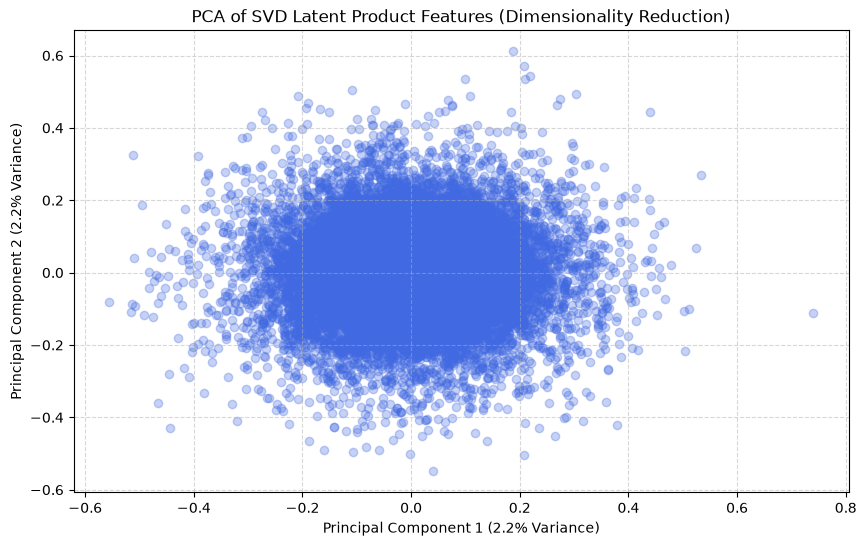

Explainability Note: The PCA plot visualizes the dimensionality reduction inherent in SVD.
Products plotted closer together share similar latent characteristics and user interaction patterns.

Training Random Forest Surrogate Model for SHAP Explainability...


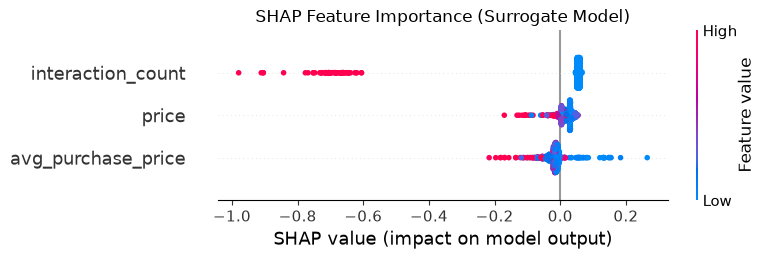

Explainability Note: The SHAP plot reveals how price and interaction counts influence the predicted ratings.

Bias Audit: Optimized Model RMSE by Socioeconomic Proxy (Price Tier)
-----------------------------------------------------------------
Shopper Segment: Budget     | RMSE: 1.3005 | Sample Size: 6735
Shopper Segment: Mid-Range  | RMSE: 1.3145 | Sample Size: 6661
Shopper Segment: Premium    | RMSE: 1.3471 | Sample Size: 6975

--- Fairness Analysis & Mitigation ---
Analyze if the optimized model still shows algorithmic bias (higher RMSE) against the 'Budget' segment.
If disparities exist, mitigations include:
1. Post-processing constraints to equalize the error rates across tiers.
2. Enhancing the dataset with additional features (Content-Based) to give the model more context on lower-tier interactions.


In [19]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

# Re-create the train/test split to audit the optimized model on unseen data
trainset, testset = train_test_split(data_surprise, test_size=0.2, random_state=42)

# Retrain our best model specifically on this trainset for a fair evaluation
print("\nTraining optimized model for bias audit...")
best_model.fit(trainset)

# ---------------------------------------------------------
# EXPLAINABILITY & DIMENSIONALITY REDUCTION (PCA)
# Extract the 50 latent factors (embeddings) learned by the SVD model for all items
# Note: 'best_model.qi' only exists AFTER the model is fitted!
item_factors = best_model.qi

# Apply PCA to reduce the 50 dimensions down to 2 dimensions for visualization
pca = PCA(n_components=2)
item_pca = pca.fit_transform(item_factors)

# Visualize the clustering tendency of the latent space
plt.figure(figsize=(10, 6))
plt.scatter(item_pca[:, 0], item_pca[:, 1], alpha=0.3, color='royalblue')
plt.title('PCA of SVD Latent Product Features (Dimensionality Reduction)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Explainability Note: The PCA plot visualizes the dimensionality reduction inherent in SVD.")
print("Products plotted closer together share similar latent characteristics and user interaction patterns.\n")

# ---------------------------------------------------------
# EXPLAINABILITY: SURROGATE MODEL WITH SHAP
# Because SVD is a black-box matrix factorization technique, we train a 
# Random Forest surrogate model on our engineered features to enable SHAP.
# ---------------------------------------------------------
print("Training Random Forest Surrogate Model for SHAP Explainability...")

# Define features (X) and target (y)
X_explain = df[['price', 'interaction_count', 'avg_purchase_price']]
y_explain = df['rating']

# Train a lightweight Random Forest
surrogate_model = RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42)
surrogate_model.fit(X_explain, y_explain)

# Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(surrogate_model)

# To save computational time, we sample 1000 random interactions for the SHAP plot
X_sample = X_explain.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Plot the SHAP Summary Plot
plt.figure(figsize=(8, 5))
plt.title("SHAP Feature Importance (Surrogate Model)")
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

print("Explainability Note: The SHAP plot reveals how price and interaction counts influence the predicted ratings.\n")
# ---------------------------------------------------------

# Generate predictions on the unseen testset
optimized_predictions = best_model.test(testset)

# Map each user_id to their engineered socioeconomic proxy (price tier)
user_tier_map = dict(zip(df['user_id'], df['price_tier']))

# Group the model's test predictions by the user's socioeconomic tier
predictions_by_tier = defaultdict(list)
for pred in optimized_predictions:
    tier = user_tier_map[pred.uid]
    predictions_by_tier[tier].append(pred)

# Calculate and print the RMSE for each individual socioeconomic group
print("Bias Audit: Optimized Model RMSE by Socioeconomic Proxy (Price Tier)")
print("-" * 65)
for tier, group_preds in predictions_by_tier.items():
    group_rmse = accuracy.rmse(group_preds, verbose=False)
    print(f"Shopper Segment: {tier: <10} | RMSE: {group_rmse:.4f} | Sample Size: {len(group_preds)}")

# Output a proposed mitigation strategy based on the audit
print("\n--- Fairness Analysis & Mitigation ---")
print("Analyze if the optimized model still shows algorithmic bias (higher RMSE) against the 'Budget' segment.")
print("If disparities exist, mitigations include:")
print("1. Post-processing constraints to equalize the error rates across tiers.")
print("2. Enhancing the dataset with additional features (Content-Based) to give the model more context on lower-tier interactions.")

In [20]:
import pickle

# Define the exact absolute path for your models directory
models_dir = r"C:\Users\Nathan\OneDrive\Documents\AIM\Capstone Project\models"

# Create the models directory if it doesn't exist yet
os.makedirs(models_dir, exist_ok=True)

# 1. Save the optimized SVD model
with open(os.path.join(models_dir, 'svd_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

# 2. Save the list of unique product IDs (the API needs this to know what to recommend)
unique_products = df['product_id'].unique().tolist()
with open(os.path.join(models_dir, 'unique_products.pkl'), 'wb') as f:
    pickle.dump(unique_products, f)

print(f"Model and product list successfully saved to:\n{models_dir}")

Model and product list successfully saved to:
C:\Users\Nathan\OneDrive\Documents\AIM\Capstone Project\models
